<a href="https://colab.research.google.com/github/atanasovmi/Quantum-/blob/main/QAOA_MAXCUT_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# CELL 1: SETUP (RUN THIS FIRST)
# ==========================================
# Installing Qiskit and NetworkX for graph visualization
!pip install qiskit[visualization] qiskit-ibm-runtime networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
import numpy as np

print("✅ Setup Complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=374b38baae30164b31c51821c91f758104ab59a953dbd4e23eb0efc74fc7703b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
✅ Setup Complete!


The Red Lines represent conflicts we want to 'cut'.


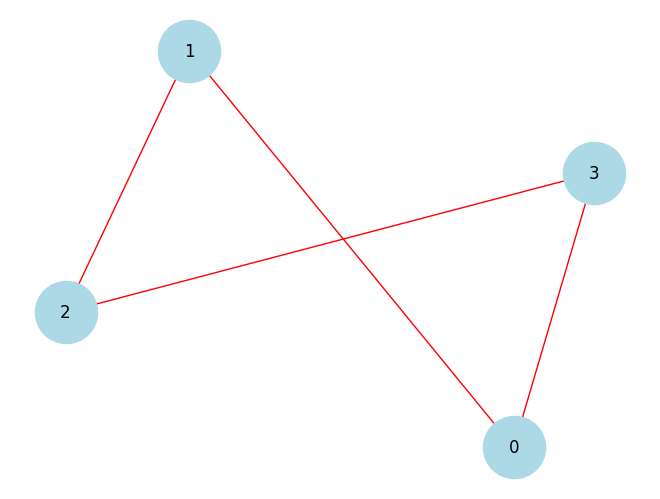

In [ ]:
# ==========================================
# PART 1: THE BUSINESS PROBLEM
# ==========================================
# SCENARIO:
# You are a manager forming two teams (Team 0 and Team 1).
# You have 4 employees (Nodes 0, 1, 2, 3).
# Some employees do NOT get along (Edges).
# GOAL: Assign employees to teams to MAXIMIZE the number of separated enemies.
# (i.e., If A hates B, put A in Team 0 and B in Team 1).

# This is the "MaxCut" problem.
# In Finance, this is identical to "Portfolio Diversification" (separating correlated assets).

# 1. Define the conflicts (edges)
# List of tuples: (Person_A, Person_B)
conflicts = [(0, 1), (1, 2), (2, 3), (3, 0)]

# 2. Visualize the Graph
G = nx.Graph()
G.add_edges_from(conflicts)
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='red', node_size=2000)
print("The Red Lines represent conflicts we want to 'cut'.")

In [ ]:
# ==========================================
# TASK 1: DEFINE THE COST FUNCTION
# ==========================================
# In Quantum, we define the problem as an "Operator" (Hamiltonian).
# We want to penalize agreements and reward disagreements.
# The math for MaxCut simplifies to checking neighboring Qubits (ZZ interaction).

# We need to build a Pauli Operator.
# For 4 qubits, an interaction between Qubit 0 and Qubit 1 is "IIZZ" (Order is q3, q2, q1, q0).
# WAIT! Qiskit order is reversed. "ZZII" usually means Z on q3 and q2.
# Let's trust the library helpers or list explicitly.

# We will define terms like ("ZZII", 1.0)
# TODO: Create the list of Pauli strings for our graph.
# Hint: For every edge (u, v), we add a ZZ term.
# Since we have 4 qubits, strings are length 4.

# Example: Edge (0,1) -> Apply Z to index 0 and 1 -> "IIZZ" (Reading right-to-left)
pauli_list = [
    ("IIZZ", 1.0),  # Edge between 0 and 1
    # TODO: Add the term for Edge (1, 2) -> "IZZI"
    # ...
    # TODO: Add the term for Edge (2, 3) -> "ZZII"
    # ...
    # TODO: Add the term for Edge (3, 0) -> "ZIIZ" (Z on 3 and 0)
    # ...
]

# Create the Operator
# cost_operator = SparsePauliOp.from_list(pauli_list)
# print(f"Operator:\n{cost_operator}")

In [ ]:
# ==========================================
# TASK 2: THE QAOA CIRCUIT
# ==========================================
# We don't need to build gates manually. Qiskit has a pre-built QAOA circuit.
# It acts like a template.

# TODO: Initialize the QAOAAnsatz
# Pass the 'cost_operator' and set 'reps=2' (depth of the circuit)
# qaoa_circuit = ...

# Measure all qubits
# qaoa_circuit.measure_all()

# Draw it to see the complexity
# qaoa_circuit.draw('mpl', fold=-1)

In [ ]:
# ==========================================
# TASK 3: OPTIMIZATION (RUNNING IT)
# ==========================================
# In a real scenario, we would use a classical optimizer (like COBYLA) to find the best angles.
# To save time, we will run it with RANDOM angles to see how the quantum computer
# "explores" the solution space.

# 1. Generate random parameters (betas and gammas)
# num_params = qaoa_circuit.num_parameters
# random_angles = np.random.uniform(0, 2*np.pi, num_params)

# 2. Run on the Sampler
sampler = StatevectorSampler()

# TODO: Run the job
# Note: The input syntax is [(circuit, parameters)]
# job = ...

# 3. Get results
# result = job.result()[0]
# counts = result.data.meas.get_counts()

# 4. Visualize
# Look for the "Highest Bars". Those are the best solutions found so far.
# plot_histogram(counts)

In [ ]:
# ==========================================
# BONUS: INTERPRETATION
# ==========================================
# 0 = Team A
# 1 = Team B
# Look at your highest bar (e.g., '0101').
# Who is in Team A? Who is in Team B?
# Does this solve the conflict graph?